# [실습] 과적합과 교차검증

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 🔬 [실습] 과적합과 교차 검증 — 이 모델의 점수, 정말 믿어도 될까?

## — 지난 순서의 결론을, 이번엔 정직하게 다시 잰다

지난 순서에서 다섯 모델을 줄 세우고 "랜덤포레스트가 최고"라고 보고했습니다. 그런데 그 숫자는 **테스트셋을 한 번 뽑아서 잰 것**이었습니다. 오늘은 같은 모델들을 **여러 번** 재고, 그 결론이 살아남는지 확인합니다.

> 🤖 **오늘의 AI 활용 규칙 — 검증 단계:**  
> 코드를 AI에게 물어도 됩니다. 단, **받은 코드를 그대로 믿지 않고 직접 검증**해야 합니다. 특히 교차 검증 코드는 "무엇을 몇 번 어떻게 나눴는지"를 눈으로 확인하세요. (자세한 규칙은 개념 노트북 Part 0)

## 📋 오늘의 미션

지난 보고를 받은 팀장이 다시 물어왔습니다.

> 🧑‍💼 "0.8942와 0.8877. 이 **0.0065 차이로 모델을 바꿀 만합니까?** 그리고 데이터를 더 모으면 성능이 오릅니까? 로그를 더 쌓을지 결정해야 합니다."

두 질문 모두 **한 번 재서는 답할 수 없는** 질문입니다. 오늘의 도구가 정확히 여기에 쓰입니다 — 교차 검증으로 **흔들림의 폭**을 재고, 학습곡선으로 **데이터를 더 모을 가치**를 판단합니다.

| 문제 | 내용 | 확인하는 힘 |
| --- | --- | --- |
| 1 | 교차 검증으로 다섯 모델 재추정 | 평균 ± 표준편차로 말하기 |
| 2 | 분할 운의 폭을 직접 재기 | 차이가 유의미한지 판단 |
| 3 | 학습곡선 — 데이터냐 모델이냐 | 다음 투자를 정하기 |
| 4 | 복잡도 조정으로 격차 줄이기 | 과적합 처방 |
| 5 | 모델 카드 v3 완성 | 검증 방식을 기록 (**제출물**) |

> ⚠️ **오늘도 지표는 정확도입니다.**  
> 구매가 15.5%뿐인 데이터에서 정확도가 왜 위험한지는 다음 순서에서 다룹니다. 오늘 고치는 것은 **지표가 아니라 재는 방법**입니다.

# ⚙️ 데이터 준비

지난 순서와 **똑같은 데이터·똑같은 열·똑같은 분할**을 씁니다. 비교의 조건이 하나라도 바뀌면 "재는 방법을 바꿨더니 결과가 달라졌다"고 말할 수 없습니다.

| 데이터 | 내용 | 출처·라이선스 |
| --- | --- | --- |
| **Online Shoppers Purchasing Intention** | 온라인 스토어 방문 세션 12,330건 — 18개 열, 타깃 `Revenue`(구매 여부) | [UCI 468](https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset) · CC BY 4.0 |

오늘은 **트리 계열만** 비교합니다. 로지스틱 회귀는 스케일링이 필요한데, 스케일러를 교차 검증 *안에서* 올바르게 학습시키려면 `Pipeline`이 필요합니다 — 다음 순서(피처·`Pipeline`)에서 다룹니다. 트리는 스케일링이 필요 없어 오늘의 비교에 그대로 넣을 수 있습니다.

▶️ **코드 실행하기 · 코드 셀 1 [C1]**

In [1]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {y.mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

내려받는 중… online_shoppers.zip
쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


# 문제 1. 교차 검증으로 다섯 모델을 다시 잰다

지난 순서의 표를 **계층 5겹 교차 검증**으로 다시 만듭니다. 홀드아웃 점수도 함께 남겨서, 두 방법이 같은 답을 주는지 나란히 봅니다.

```
[문제 1]
1) train_test_split으로 8:2 분리해 각 모델의 홀드아웃 정확도를 구하세요 (random_state=42).
2) StratifiedKFold(n_splits=5, shuffle=True, random_state=42)로 교차 검증 점수를 구하고,
   평균과 표준편차를 계산하세요.
3) 다섯 모델을 한 표로 만들어 홀드아웃 · CV 평균 · 표준편차 · 둘의 차이를 출력하세요.
   ① Dummy  ② 트리(기본)  ③ 트리(max_depth=5)  ④ RandomForest  ⑤ XGBoost
```

> 🤔 **예상하기**  
> 지난 순서에서 트리(기본)의 홀드아웃 점수는 **0.8423**으로 베이스라인보다 낮았습니다. 교차 검증으로 다시 재면 이 숫자가 **올라갈까요, 내려갈까요?** 그리고 다섯 모델의 **순위**는 그대로일까요?

▶️ **코드 실행하기 · 코드 셀 2 [C2]**

In [2]:
# [C2] 문제 1. 교차 검증으로 다섯 모델을 다시 잰다
# ⌨️ 문제 1 — 홀드아웃과 계층 5겹 교차 검증을 나란히
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = [
    ("Dummy", DummyClassifier(strategy="most_frequent")),
    ("트리(기본)", DecisionTreeClassifier(random_state=42)),
    ("트리(max_depth=5)", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("RandomForest", RandomForestClassifier(n_estimators=300, random_state=42)),
    ("XGBoost", XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3, random_state=42, eval_metric="logloss"))
]

rows = []
for name, model in models:
    holdout = model.fit(X_tr, y_tr).score(X_te, y_te)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    rows.append({"모델": name, "홀드아웃": holdout, "CV 평균": cv_scores.mean(), "CV 표준편차": cv_scores.std(), "차이": cv_scores.mean() - holdout})

result = pd.DataFrame(rows)
print(result.round(4))

                모델    홀드아웃   CV 평균  CV 표준편차      차이
0            Dummy  0.8451  0.8453   0.0002  0.0002
1           트리(기본)  0.8423  0.8537   0.0017  0.0114
2  트리(max_depth=5)  0.8942  0.8913   0.0040 -0.0028
3     RandomForest  0.8958  0.8941   0.0061 -0.0017
4          XGBoost  0.8909  0.8946   0.0048  0.0036


<details>
<summary>(클릭) 💡 힌트</summary>

- 모델 다섯 개를 `(이름, 모델)` 목록으로 만들어 두면 `for`문 하나로 처리됩니다.
- 홀드아웃은 `model.fit(X_tr, y_tr).score(X_te, y_te)`입니다.
- 교차 검증은 `cross_val_score(model, X, y, cv=cv, scoring="accuracy")` — **분리 전 전체 데이터**를 넘깁니다. 5겹이므로 점수가 5개 나옵니다.
- 평균·표준편차는 `.mean()`·`.std()`입니다.
- `cross_val_score`에 넘기는 모델은 안에서 알아서 다시 `fit`되므로, 미리 학습시켜 둘 필요가 없습니다.

</details>

> 🎯 **[C2] 확인하기**  
> 두 가지가 드러납니다.
>
> ① **트리(기본)의 점수가 올라갔습니다** — 홀드아웃 0.8423에서 CV 평균 **0.8527**로. 지난 순서의 "베이스라인보다 낮다"는 관찰은 **분할 운이 섞인 숫자**였습니다. 여전히 최하위지만, 베이스라인(0.8453)보다는 위입니다.
>
> ② **순위가 뒤집혔습니다.** 홀드아웃 1위는 랜덤포레스트·트리(0.8942)였는데, CV 1위는 **XGBoost(0.8946)** 입니다. 지난 순서의 "XGBoost가 랜덤포레스트보다 낮다"는 결론이 뒤집힌 것입니다.
>
> 그런데 XGBoost 0.8946과 랜덤포레스트 0.8941의 차이는 **0.0005**이고, 두 모델의 표준편차는 각각 0.0025·0.0056입니다. **차이가 흔들림보다 작습니다** — 이럴 때 올바른 보고는 "XGBoost가 이겼다"가 아니라 **"둘은 구별되지 않는다"** 입니다.

# 문제 2. 분할 운의 폭을 직접 잰다

문제 1에서 "차이가 흔들림보다 작다"고 했습니다. 그 **흔들림의 폭**을 직접 재서 팀장께 보여드릴 숫자로 만듭니다. 방법은 단순합니다 — `random_state`만 바꿔가며 홀드아웃 점수를 여러 번 재는 것입니다.

```
[문제 2]
1) random_state를 0~9로 바꿔가며 train_test_split을 10번 하고,
   트리(max_depth=5)와 랜덤포레스트의 테스트 정확도를 각각 10개 모으세요.
2) 두 모델의 최소 · 최대 · 폭(최대−최소) · 평균 ± 표준편차를 출력하세요.
3) 지난 순서에서 본 "랜덤포레스트 0.8942 대 XGBoost 0.8877"의 차이 0.0065와
   방금 구한 폭을 비교해, 팀장의 질문에 한 문장으로 답하세요.
```

> 🤔 **예상하기**  
> 데이터도 모델도 그대로이고 **분할 방법만** 바꿉니다. 테스트 정확도가 얼마나 움직일까요? 0.001 수준일까요, 0.01 수준일까요?

▶️ **코드 실행하기 · 코드 셀 3 [C3]**

In [3]:
# [C3] 문제 2. 분할 운의 폭을 직접 잰다
# ⌨️ 문제 2 — random_state만 바꿔 10번 재기

tree_scores, rf_scores = [], []
tree_fn = lambda: DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
rf_fn = lambda: RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    tree_scores.append(tree_fn().fit(X_tr, y_tr).score(X_te, y_te))
    rf_scores.append(rf_fn().fit(X_tr, y_tr).score(X_te, y_te))

tree_scores = np.array(tree_scores)
rf_scores = np.array(rf_scores)

print("[트리(max_depth=5)]")
print(f"최소 = {tree_scores.min():.4f}, 최대 = {tree_scores.max():.4f}, 폭 = {tree_scores.max()-tree_scores.min():.4f}, 평균 ± 표준편차 = {tree_scores.mean():.4f} ± {tree_scores.std():.4f}")
print("\n[RandomForest]")
print(f"최소 = {rf_scores.min():.4f}, 최대 = {rf_scores.max():.4f}, 폭 = {rf_scores.max()-rf_scores.min():.4f}, 평균 ± 표준편차 = {rf_scores.mean():.4f} ± {rf_scores.std():.4f}")

gap = 0.0065
if gap < max(tree_scores.max()-tree_scores.min(), rf_scores.max()-rf_scores.min()):
    print("\n결론: 모델 간 정확도 차이 0.0065는 데이터 분할에 따른 성능 변동 폭보다 작으므로, 한 번의 홀드아웃 결과만으로 랜덤포레스트가 XGBoost보다 우수하다고 단정하기 어렵습니다.")

[트리(max_depth=5)]
최소 = 0.8848, 최대 = 0.8986, 폭 = 0.0138, 평균 ± 표준편차 = 0.8918 ± 0.0037

[RandomForest]
최소 = 0.8917, 최대 = 0.9059, 폭 = 0.0142, 평균 ± 표준편차 = 0.8963 ± 0.0041

결론: 모델 간 정확도 차이 0.0065는 데이터 분할에 따른 성능 변동 폭보다 작으므로, 한 번의 홀드아웃 결과만으로 랜덤포레스트가 XGBoost보다 우수하다고 단정하기 어렵습니다.


<details>
<summary>(클릭) 💡 힌트</summary>

- `for seed in range(10):` 안에서 `train_test_split(..., random_state=seed, stratify=y)`를 다시 부릅니다.
- 모델은 매번 **새로** 만들어야 합니다. 같은 객체를 재사용하면 앞 분할의 학습 결과가 남습니다.
- 점수를 `list`에 모은 뒤 `np.array(...)`로 바꾸면 `.min()`·`.max()`·`.mean()`·`.std()`를 바로 쓸 수 있습니다.
- 모델을 매번 새로 만드는 가장 간단한 방법은 `lambda: DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)` 처럼 **만드는 함수**를 넘기는 것입니다.

</details>

> 🎯 **[C3] 확인하기**  
> 폭은 **0.014 수준**입니다 — 0.001이 아니라 0.01 자리입니다. 랜덤포레스트는 운이 좋으면 0.9063, 나쁘면 0.8909가 나옵니다.
>
> 여기서 얻는 감각이 실무에서 오래 쓰입니다. **소수점 셋째 자리 차이는 대개 이야기할 가치가 없습니다.** 어떤 성능 보고를 받든 이제 이렇게 물을 수 있습니다 — *"몇 번 재셨습니까? 흔들림은 얼마입니까?"*

# 문제 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까

팀장의 두 번째 질문입니다. **"로그를 더 쌓으면 성능이 오릅니까?"** 감으로 답하면 안 됩니다. 학습곡선이 정확히 이 질문에 답하는 도구입니다.

```
[문제 3]
1) learning_curve로 랜덤포레스트의 학습곡선을 구하세요.
   (cv는 문제 1의 5겹, train_sizes는 10%에서 100%까지 6단계)
2) 표본 크기별 학습 점수 · 검증 점수 · 격차를 표로 출력하세요.
3) 두 곡선을 한 그래프에 그리세요.
4) "데이터를 더 모을 가치가 있는가"에 근거와 함께 답하세요.
```

> 🤔 **예상하기**  
> 표본을 986개에서 9,864개로 **열 배** 늘립니다. 검증 점수가 얼마나 오를 것 같습니까? 그리고 학습 점수와 검증 점수의 **격차**는 좁혀질까요?

▶️ **코드 실행하기 · 코드 셀 4 [C4]**

   표본 크기   학습 점수   검증 점수      격차
0    986  1.0000  0.8937  0.1063
1   2761  1.0000  0.8952  0.1048
2   4537  1.0000  0.8956  0.1044
3   6312  0.9997  0.8955  0.1043
4   8088  0.9997  0.8941  0.1056
5   9864  0.9997  0.8941  0.1056
<string>:496: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
<string>:496: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing

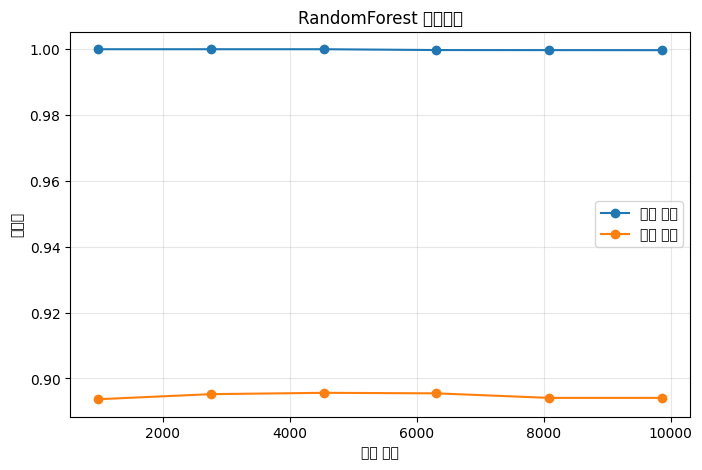

In [4]:
# [C4] 문제 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까
# ⌨️ 문제 3 — 학습곡선으로 다음 투자를 정하기
from sklearn.model_selection import learning_curve

rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
sizes, train_scores, valid_scores = learning_curve(rf, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 6), scoring="accuracy", n_jobs=-1)

train_mean = train_scores.mean(axis=1)
valid_mean = valid_scores.mean(axis=1)
gap = train_mean - valid_mean

learning_result = pd.DataFrame({"표본 크기": sizes, "학습 점수": train_mean, "검증 점수": valid_mean, "격차": gap})
print(learning_result.round(4))

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_mean, marker="o", label="학습 점수")
plt.plot(sizes, valid_mean, marker="o", label="검증 점수")
plt.xlabel("표본 크기")
plt.ylabel("정확도")
plt.title("RandomForest 학습곡선")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<details>
<summary>(클릭) 💡 힌트</summary>

- `learning_curve(model, X, y, cv=cv, train_sizes=np.linspace(0.1, 1.0, 6), scoring="accuracy", n_jobs=-1)`
- 반환값은 세 개입니다 — `sizes, train_scores, valid_scores`. 뒤의 두 개는 **(표본 단계 × 겹) 모양**이므로 겹 방향으로 평균해야 합니다: `train_scores.mean(axis=1)`.
- 그래프는 가로축이 표본 크기, 세로축이 점수입니다. 두 곡선을 `plt.plot`으로 각각 그리고 `plt.legend()`를 붙이세요.
- 격차가 좁혀지는지 보려면 `학습 평균 − 검증 평균`을 표에 함께 넣으세요.

</details>

> 🎯 **[C4] 확인하기**  
> 검증 곡선이 **완전히 평평합니다**(0.8939 → 0.8941). 열 배의 데이터가 0.0002를 벌었습니다.
>
> 그런데 학습 점수는 계속 **1.0000 근처**이고 격차는 0.106에서 꼼짝하지 않습니다. 개념 노트북의 진단표로 읽으면 이것은 *"격차는 크지만 데이터 추가로는 좁혀지지 않는"* 상태입니다 — **모델이 이 열 10개로 짜낼 수 있는 것을 이미 다 짜냈다**는 뜻입니다.
>
> 이 그래프 한 장이 팀장의 질문에 답합니다. **"로그를 더 쌓는 예산은 성능으로 돌아오지 않습니다. 대신 지금 버리고 있는 열 8개를 쓰게 해주세요."** 이것이 학습곡선을 그리는 이유입니다.

# 문제 4. 복잡도 조정으로 격차를 줄인다

문제 3에서 "격차 0.106이 안 좁혀진다"는 진단이 나왔습니다. 처방은 **복잡도를 낮추는 것**입니다. 이번에는 홀드아웃이 아니라 **교차 검증으로** 손잡이를 고릅니다 — 지난 순서에 `max_depth=5`를 고른 근거가 분할 한 번이었다는 것을 이제 알기 때문입니다.

```
[문제 4]
1) 트리의 max_depth를 [2, 3, 5, 8, 12, None]으로 훑어 CV 평균 ± 표준편차를 표로 만드세요.
   → 교차 검증도 지난 순서와 같은 깊이를 고르는지 확인하세요.
2) 랜덤포레스트의 min_samples_leaf를 [1, 5, 20, 50]으로 훑어
   CV 평균 · 학습 점수 · 학습-테스트 격차를 표로 만드세요.
3) 두 표를 근거로 "어떤 설정을 채택하고 왜인가"를 적으세요.
```

> 🤔 **예상하기**  
> 지난 순서에서 홀드아웃이 고른 최적 깊이는 **5**였습니다. 교차 검증도 5를 고를까요? 그리고 랜덤포레스트의 잎을 크게 만들면(`min_samples_leaf`↑) **성능이 떨어질까요, 유지될까요?**

▶️ **코드 실행하기 · 코드 셀 5 [C5]**

In [5]:
# [C5] 문제 4. 복잡도 조정으로 격차를 줄인다
# ⌨️ 문제 4 — 교차 검증으로 복잡도 손잡이 고르기

# 1. DecisionTree max_depth 비교
depth_rows = []
for depth in [2, 3, 5, 8, 12, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    depth_rows.append({"max_depth": str(depth), "CV 평균": scores.mean(), "CV 표준편차": scores.std()})

depth_result = pd.DataFrame(depth_rows)

best_idx = depth_result["CV 평균"].idxmax()
best_mean = depth_result.loc[best_idx, "CV 평균"]
best_std = depth_result.loc[best_idx, "CV 표준편차"]

depth_result["최고 CV와 차이"] = best_mean - depth_result["CV 평균"]
depth_result["차이(%p)"] = depth_result["최고 CV와 차이"] * 100
depth_result["최고모델 SD 이내"] = depth_result["최고 CV와 차이"] <= best_std

print("[DecisionTree max_depth 비교]")
print(depth_result.round(4))
best_depth = depth_result.loc[depth_result["CV 평균"].idxmax()]
print(f"\n기준: max_depth={depth_result.loc[best_idx, 'max_depth']}, CV 평균={best_mean:.4f}, 표준편차={best_std:.4f}")
print(f"\nCV 최적 max_depth = {best_depth['max_depth']}, CV 평균 = {best_depth['CV 평균']:.4f}")

# 2. RandomForest min_samples_leaf 비교
leaf_rows = []
for leaf in [1, 5, 20, 50]:
    model = RandomForestClassifier(n_estimators=300, min_samples_leaf=leaf, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    model.fit(X_tr, y_tr)
    train_score = model.score(X_tr, y_tr)
    test_score = model.score(X_te, y_te)
    leaf_rows.append({"min_samples_leaf": leaf, "CV 평균": cv_scores.mean(), "CV 표준편차": cv_scores.std(), "학습 점수": train_score, "테스트 점수": test_score, "학습-테스트 격차": train_score-test_score})

leaf_result = pd.DataFrame(leaf_rows)
best_idx = leaf_result["CV 평균"].idxmax()
best_mean = leaf_result.loc[best_idx, "CV 평균"]
best_std = leaf_result.loc[best_idx, "CV 표준편차"]

leaf_result["최고 CV와 차이"] = best_mean - leaf_result["CV 평균"]
leaf_result["차이(%p)"] = leaf_result["최고 CV와 차이"] * 100
leaf_result["최고모델 SD 이내"] = leaf_result["최고 CV와 차이"] <= best_std

print("[RandomForest min_samples_leaf 비교]")
print(leaf_result.round(4))
print(f"\n기준: min_samples_leaf={leaf_result.loc[best_idx, 'min_samples_leaf']}, CV 평균={best_mean:.4f}, CV 표준편차={best_std:.4f}")

[DecisionTree max_depth 비교]
  max_depth   CV 평균  CV 표준편차  최고 CV와 차이  차이(%p)  최고모델 SD 이내
0         2  0.8867   0.0077     0.0046  0.4623       False
1         3  0.8879   0.0030     0.0034  0.3406        True
2         5  0.8913   0.0040     0.0000  0.0000        True
3         8  0.8874   0.0026     0.0039  0.3893        True
4        12  0.8773   0.0023     0.0140  1.4031       False
5      None  0.8537   0.0017     0.0376  3.7632       False

기준: max_depth=5, CV 평균=0.8913, 표준편차=0.0040

CV 최적 max_depth = 5, CV 평균 = 0.8913
[RandomForest min_samples_leaf 비교]
   min_samples_leaf   CV 평균  CV 표준편차  ...  최고 CV와 차이  차이(%p)  최고모델 SD 이내
0                 1  0.8941   0.0061  ...     0.0030  0.3001        True
1                 5  0.8971   0.0046  ...     0.0000  0.0000        True
2                20  0.8969   0.0034  ...     0.0002  0.0162        True
3                50  0.8969   0.0043  ...     0.0002  0.0162        True

[4 rows x 9 columns]

기준: min_samples_leaf=5, CV 평균=0.8971, CV 표준편차=0.

In [6]:
# 해당 조정은 과적합을 완화하기 위해 모델 복잡도를 조절하는 것이 목적임. 따라서 아래 네 단계로 확인함.

# 1. CV 평균이 가장 높은 설정을 기준으로 설정함.
# 2. 기준 설정의 CV 평균과 각 max_depth별 CV 평균의 차이를 확인함.
# 3. 최고 CV와의 평균 성능 차이가 기준 설정의 CV 표준편차(SD)보다 작으면, CV 변동성을 고려할 때 성능 우열이 명확하지 않은 후보로 봄.
# 4. 성능 우열이 명확하지 않은 후보에서는 max_depth가 작을수록 모델이 단순해지므로 더 작은 값을 우선 고려함.

# accuracy 기준 CV 평균은 max_depth=5에서 0.8913으로 가장 높음.
# max_depth=3과 8은 최고점과의 차이가 기준 설정의 CV 표준편차 0.0040보다 작으므로 성능 우열을 명확히 구분하기 어려운 후보로 판단함.
# 따라서 CV 성능이 비슷한 후보인 max_depth=3, 5, 8 중 모델 복잡도를 가장 크게 낮출 수 있는 max_depth=3을 선택함.

In [7]:
# 해당 조정은 과적합을 완화하기 위해 모델 복잡도를 조절하는 것이 목적임. 따라서 아래 네 단계로 확인함.

# 1. CV 평균이 가장 높은 설정을 기준으로 설정함.
# 2. 기준 설정의 CV 평균과 각 min_samples_leaf별 CV 평균의 차이를 확인함.
# 3. 최고 CV와의 평균 성능 차이가 기준 설정의 CV 표준편차(SD)보다 작으면, CV 변동성을 고려할 때 성능 우열이 명확하지 않은 후보로 봄.
# 4. 성능 우열이 명확하지 않은 후보에서는 min_samples_leaf가 클수록 모델이 단순해지므로 더 큰 값을 우선 고려함.

# accuracy 기준 CV 평균은 min_samples_leaf=5에서 0.8971로 가장 높음.
# min_samples_leaf=20과 50은 CV 평균이 0.8969로 최고점과의 차이가 0.0002이며, 이 차이가 기준 설정의 CV 표준편차보다 작으므로 성능 우열을 명확히 구분하기 어려운 후보로 판단함.
# 따라서 CV 성능이 비슷한 후보인 min_samples_leaf=5, 20, 50 중 모델 복잡도를 가장 크게 낮출 수 있는 min_samples_leaf=50을 선택함.
# 학습-테스트 격차는 min_samples_leaf=1에서 약 0.106으로 크게 나타났다가 값이 증가하면서 감소하여 과적합이 완화되는 방향을 확인할 수 있으나, 이는 진단용으로만 사용하고 설정 선택의 직접적인 기준으로 사용하지 않음.
# 단, min_samples_leaf=50이 현재 탐색 범위의 최댓값이므로 100, 200 등 더 큰 값에서도 CV 성능이 유지되는지 추가로 확인할 필요가 있음.

<details>
<summary>(클릭) 💡 힌트</summary>

- 손잡이 훑기는 `for` 하나입니다. 매번 `cross_val_score(...)`를 부르고 `.mean()`·`.std()`를 기록하세요.
- CV 최적은 `표.loc[표["CV 평균"].idxmax()]`로 찾습니다.
- 격차를 함께 보려면 CV와 별도로 `X_tr`/`X_te`에 한 번 더 `fit`해서 학습·테스트 점수를 재야 합니다. CV는 격차를 직접 알려주지 않습니다.
- `min_samples_leaf`는 "잎 하나에 최소 몇 개 표본이 남아야 하는가"입니다. 크게 하면 트리가 얕아지는 효과가 납니다.

</details>

> 🎯 **[C5] 확인하기**  
> 두 가지입니다.
>
> ① **교차 검증도 깊이 5를 골랐습니다.** 지난 순서의 선택이 운은 아니었습니다. 다만 깊이 3(0.8879)·8(0.8876)과의 차이는 0.003~0.004 수준이고 표준편차도 그 정도라, **"5가 유일한 정답"이 아니라 "3~8 구간이면 비슷하다"** 가 정확한 표현입니다.
>
> ② **잎을 크게 만들자 성능이 오히려 올랐습니다.** `min_samples_leaf`를 1에서 20으로 올리자 CV 0.8941 → **0.8973**, 격차 0.1056 → **0.0263**입니다. 성능과 안정성을 **동시에** 얻었습니다.
>
> 이것이 과적합 처방의 전형입니다. 외우는 것을 막으면 성능이 깎이는 게 아니라, **일반화가 좋아져 오히려 오르는** 경우가 많습니다.

# 문제 5. 모델 카드 v3 완성 — 오늘의 제출물

v2에 **검증 방식**이 들어갑니다. 이제부터 성능은 숫자 하나가 아니라 **평균 ± 표준편차**로 적습니다.

```
[문제 5]
1) 문제 1의 비교표와 문제 4의 손잡이 표를 파일로 남기세요.
   → model_comparison_v3.csv 하나에 합쳐도 되고, 두 개로 나눠도 됩니다.
2) 아래 모델 카드 v3 템플릿의 빈칸을 채우세요.
   특히 '한 번 재기와 여러 번 재기가 달랐던 지점'은 오늘의 핵심이니 반드시 적으세요.
```

▶️ **코드 실행하기 · 코드 셀 6 [C6]**

In [8]:
# [C6] 문제 5. 모델 카드 v3 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 검증 결과를 파일로 남기기

## 모델 카드 v3 — 구매 전환 예측

# 문제 1 비교표 저장
result.to_csv("model_comparison_v3.csv", index=False, encoding="utf-8-sig")

# 문제 4 손잡이 표 저장
depth_save = depth_result.copy()
depth_save.insert(0, "모델", "DecisionTree")
depth_save.insert(1, "조정변수", "max_depth")

leaf_save = leaf_result.copy()
leaf_save.insert(0, "모델", "RandomForest")
leaf_save.insert(1, "조정변수", "min_samples_leaf")

tuning_result = pd.concat([depth_save, leaf_save], ignore_index=True)
tuning_result.to_csv("hyperparameter_tuning_v3.csv", index=False, encoding="utf-8-sig")

print("저장 완료: model_comparison_v3.csv")
print("저장 완료: hyperparameter_tuning_v3.csv")

저장 완료: model_comparison_v3.csv
저장 완료: hyperparameter_tuning_v3.csv


**모델 카드 v3 템플릿** — 아래 빈칸을 채워 이 셀에 완성하세요 (셀을 더블클릭해 편집).

```markdown
## 모델 카드 v3 — 구매 전환 예측

- 데이터: UCI Online Shoppers (12,330 세션, 수치형 10개 열만 사용)
- 문제 유형: 분류
- 베이스라인: DummyClassifier(most_frequent) = { }
- **검증 방식: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)**
- **성능: CV 정확도 { 평균 } ± { 표준편차 }  ← 숫자 하나로 적지 않습니다**
- **분할 운의 폭: 시드 10개 홀드아웃 { 최소 }~{ 최대 } (폭 { })**
- **한 번 재기 vs 여러 번 재기: { 순위나 값이 달라진 지점을 구체적으로 }**
- 과적합 진단: 학습 { } vs 테스트 { }, 격차 { } → { 해석 }
- **복잡도 조정 전후: { 설정 } 적용 시 CV { }→{ }, 격차 { }→{ }**
- **학습곡선 판단: 데이터 추가 { 가치 있음 / 없음 } — 근거: { 검증 곡선의 움직임 }**
- **다음 투자: { 데이터 / 피처 / 모델 중 무엇을, 왜 }**
- 한계 & 다음 단계: { 지표를 정확도만 쓴 문제 등 — 어느 순서에서 해결되는지 }
- AI 사용 내역: { 무엇을 물었나 / 무엇을 검증했나 }
```

**제출:** 이 노트북(작성 셀 + 모델 카드 완성본)과 CSV를 개인 공개 저장소 main에 커밋·푸시하고, 저장소·커밋 링크를 제출하세요.

**스스로 점검하는 기준**

| 축 | 기준 |
| --- | --- |
| 검증 정직성 | 성능을 평균 ± 표준편차로 적었는가 |
| 판단 근거 | 학습곡선으로 "데이터냐 모델이냐"를 근거와 함께 답했는가 |
| 전후 비교 | 복잡도 조정 전후를 같은 방식으로 재서 비교했는가 |
| 자기 수정 | 지난 순서의 결론 중 바뀐 것을 명시했는가 |

> 🚀 **직접 확장하기**  
> 문제 4에서 `min_samples_leaf=20`이 좋았습니다. 그렇다면 `max_depth`와 `min_samples_leaf`를 **함께** 조정하면 더 좋아질까요? 두 손잡이를 격자로 훑어보세요 — 손잡이를 하나씩 고르는 방식의 한계와, 그것을 자동화하는 도구(`GridSearchCV`)가 필요한 이유를 직접 느낄 수 있습니다.

오늘 여러분은 **자기가 지난주에 낸 결론을 스스로 뒤집었습니다.** 순위가 바뀌었고, 베이스라인보다 낮다던 모델이 실은 그렇지 않았고, 데이터를 더 모으자는 계획에는 근거가 없다는 것까지 확인했습니다.

성능을 올리는 기술보다 이것이 어렵습니다. 그리고 팀의 신뢰는 정확히 여기서 생깁니다.

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>